# Comparación temporal de ángulo — Shoulder Rotación Int/Ext
Modifica **solo la celda de configuración**. El resto se ejecuta automáticamente.

In [1]:
# ── Dependencias ─────────────────────────────────────────────────────────────
# Si falta alguna: pip install ezc3d numpy scipy matplotlib
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.signal import find_peaks
import ezc3d

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
#  CONFIGURATION  ← edit here for each specific case
# ══════════════════════════════════════════════════════════════════════════════

# -- Recordings per side ------------------------------------------------------
# Each element needs 'path' and 'label' (legend text).
SIDES_RECORDINGS = {
    "Left": [
        {"path": r"C:\Projects\data_organized\grab 5_c3d\De pie_c3d\Pie_Complete_Shoulder_Rotac_Int_Ext_Left_Cont01.c3d",  "label": "Complete"},
        {"path": r"C:\Projects\data_organized\grab 5_c3d\De pie_c3d\Pie_C7_Shoulder_Rotac_Int_Ext_Left_Cont01.c3d",        "label": "With C7"},
        {"path": r"C:\Projects\data_organized\grab 5_c3d\De pie_c3d\Pie_NOT_C7_Shoulder_Rotac_Int_Ext_Left_Cont01.c3d",    "label": "Without C7"},
    ],
    "Right": [
        {"path": r"C:\Projects\data_organized\grab 5_c3d\De pie_c3d\Pie_Complete_Shoulder_Rotac_Int_Ext_Right_Cont01.c3d", "label": "Complete"},
        {"path": r"C:\Projects\data_organized\grab 5_c3d\De pie_c3d\Pie_C7_Shoulder_Rotac_Int_Ext_Right_Cont01.c3d",       "label": "With C7"},
        {"path": r"C:\Projects\data_organized\grab 5_c3d\De pie_c3d\Pie_NOT_C7_Shoulder_Rotac_Int_Ext_Right_Cont01.c3d",   "label": "Without C7"},
    ],
}

VARIABLE_NAME   = "Humerothoracic_XZY_Op2"
COMPONENT_INDEX = 2  # Z axis
NORMALIZE_TIME  = False
SHOW_MEAN_BAND  = False

PROMINENCE          = 15.0
MIN_DISTANCE        = 60
HALFCYCLE_DIRECTION = "peak_to_valley"

COLORS     = ["#E74C3C", "#2E86C1", "#27AE60"]
ALPHA_RAW  = 0.85
ALPHA_BAND = 0.18
LINE_WIDTH = 1.5

MOVEMENT_NAME = "Shoulder Internal External Rotation"
Y_LABEL       = "Angle (°)"

OUTPUT_PATH = None
DPI         = 150

In [3]:
# ── Lectura de C3D (autónoma, sin importar data_processing.py) ───────────────

def read_c3d(filepath):
    """Lee un C3D de Vicon Nexus y devuelve frame_rate, n_frames, model_outputs."""
    filepath = os.path.normpath(os.path.abspath(filepath))
    c = ezc3d.c3d(filepath)

    raw_labels = c["parameters"]["POINT"]["LABELS"]["value"]
    point_data = c["data"]["points"]          # (4, n_labels, n_frames)
    n_labels   = min(len(raw_labels), point_data.shape[1])

    try:
        rate_val   = c["parameters"]["POINT"]["RATE"]["value"]
        frame_rate = int(float(rate_val[0]) if hasattr(rate_val, "__len__") else float(rate_val))
    except (KeyError, IndexError, TypeError, ValueError):
        frame_rate = int(c["header"]["frame_rate"])

    # Strip subject prefix before ':'
    clean_labels = [
        lbl.split(":")[-1].strip() if ":" in lbl else lbl.strip()
        for lbl in raw_labels[:n_labels]
    ]

    model_outputs = {
        lbl: point_data[:3, i, :].copy()
        for i, lbl in enumerate(clean_labels)
    }

    return {
        "frame_rate":    frame_rate,
        "n_frames":      point_data.shape[2],
        "model_outputs": model_outputs,
    }


def extract_angle(c3d_path, variable, component, side):
    """Extrae la curva angular 1D de un C3D. Devuelve (array, frame_rate)."""
    c3d   = read_c3d(c3d_path)
    label = variable if side == "—" else side + variable
    mo    = c3d["model_outputs"]

    if label not in mo:
        available = [k for k in mo if variable in k or side in k]
        raise KeyError(
            f"Label '{label}' no encontrado en {os.path.basename(c3d_path)}.\n"
            f"Coincidencias parciales: {available}\n"
            f"Labels disponibles: {list(mo.keys())}"
        )

    return mo[label][component, :].astype(float), c3d["frame_rate"]

In [4]:
# ── Segmentación (autónoma, sin importar segmentation.py) ────────────────────

def auto_segment(angle, prominence, min_distance, direction="peak_to_valley"):
    """Detecta semiciclos (peak→valley o valley→peak) y devuelve lista de (start, end)."""
    clean   = np.where(np.isnan(angle), np.nanmean(angle), angle)
    peaks,   _ = find_peaks( clean, prominence=prominence, distance=min_distance)
    valleys, _ = find_peaks(-clean, prominence=prominence, distance=min_distance)

    combined = sorted(
        [(int(f), "peak") for f in peaks] + [(int(f), "valley") for f in valleys],
        key=lambda x: x[0],
    )

    if direction == "peak_to_valley":
        want = ("peak", "valley")
    else:
        want = ("valley", "peak")

    segments = [
        (combined[i][0], combined[i + 1][0])
        for i in range(len(combined) - 1)
        if combined[i][1] == want[0] and combined[i + 1][1] == want[1]
    ]
    return segments


def mean_band(angle, prominence, min_distance, direction):
    """Segmenta las reps, interpola a 101 puntos y devuelve (t%, media, DE)."""
    segments = auto_segment(angle, prominence, min_distance, direction)
    if not segments:
        raise RuntimeError("No se detectaron repeticiones. Ajusta PROMINENCE o MIN_DISTANCE.")

    x_norm = np.linspace(0, 100, 101)
    reps   = []
    for s, e in segments:
        seg   = angle[s:e + 1]
        t_seg = np.linspace(0, 100, len(seg))
        reps.append(np.interp(x_norm, t_seg, seg))

    mat  = np.vstack(reps)
    mean = mat.mean(axis=0)
    std  = mat.std(axis=0, ddof=1) if mat.shape[0] > 1 else np.zeros(101)
    return x_norm, mean, std, len(segments)

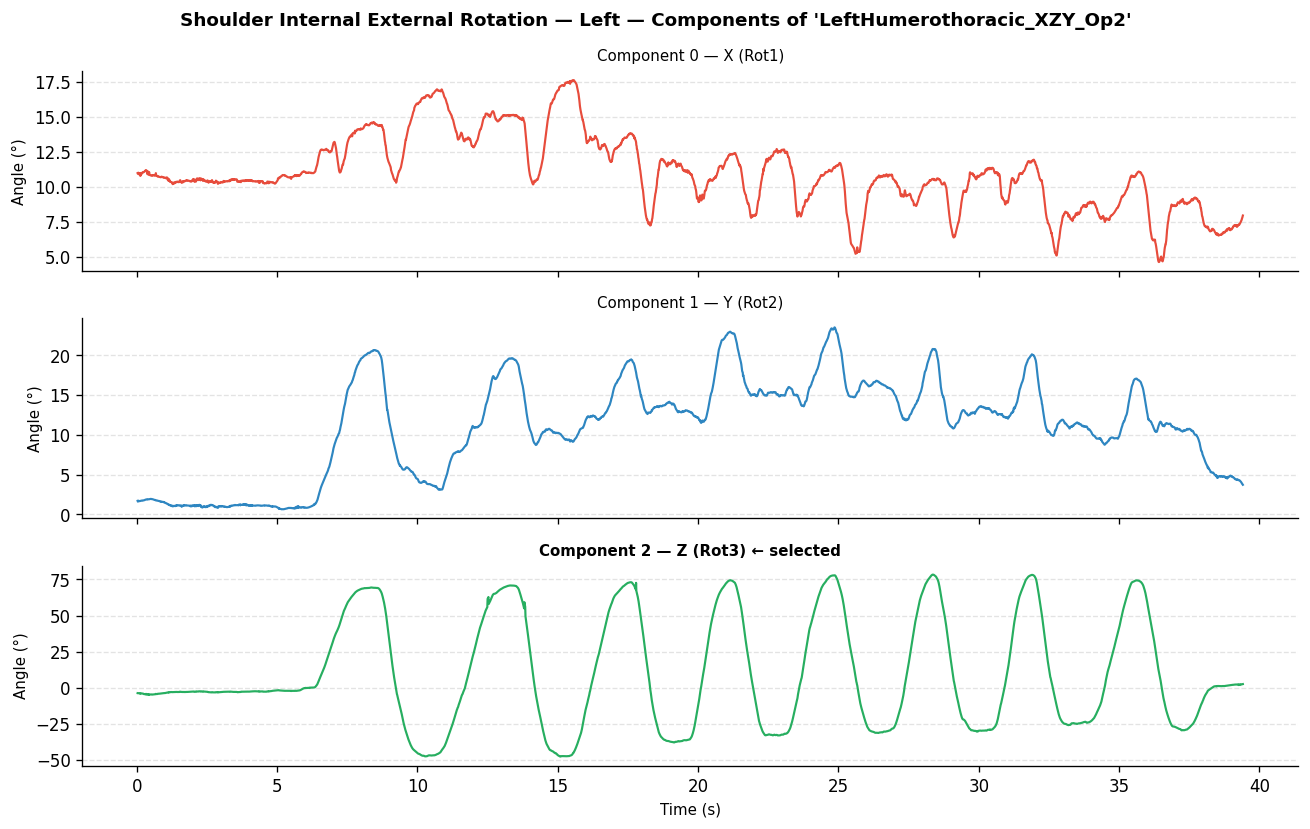

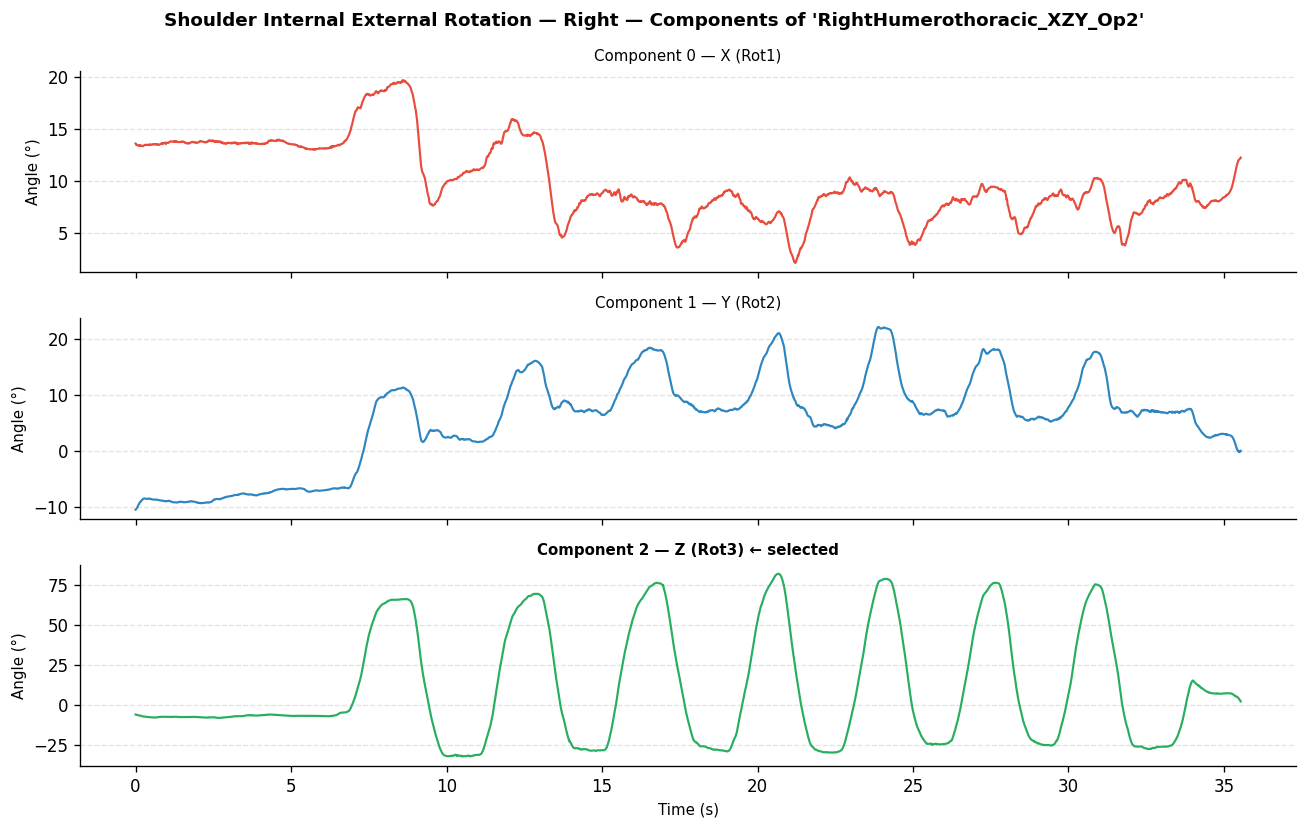

In [5]:
# ── Diagnostics: view all 3 components (X, Y, Z) of the first recording ──────
# Run this cell to identify which component corresponds to the movement
# of interest before setting COMPONENT_INDEX in the configuration.

_component_names  = ["X (Rot1)", "Y (Rot2)", "Z (Rot3)"]
_component_colors = ["#E74C3C", "#2E86C1", "#27AE60"]

for SIDE, C3D_RECORDINGS in SIDES_RECORDINGS.items():
    _rec   = C3D_RECORDINGS[0]
    _c3d   = read_c3d(_rec["path"])
    _label = VARIABLE_NAME if SIDE == "—" else SIDE + VARIABLE_NAME
    _data  = _c3d["model_outputs"][_label]
    _fr    = _c3d["frame_rate"]
    _t     = np.arange(_data.shape[1]) / _fr

    fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
    fig.suptitle(f"{MOVEMENT_NAME} — {SIDE} — Components of '{_label}'",
                 fontsize=11, fontweight="bold")

    for idx, (name, color) in enumerate(zip(_component_names, _component_colors)):
        ax = axes[idx]
        ax.plot(_t, _data[idx], color=color, linewidth=1.3)
        ax.set_ylabel("Angle (°)", fontsize=9)
        ax.set_title(f"Component {idx} — {name}"
                     + (" ← selected" if idx == COMPONENT_INDEX else ""),
                     fontsize=9, fontweight="bold" if idx == COMPONENT_INDEX else "normal")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.yaxis.grid(True, linestyle="--", alpha=0.35)

    axes[-1].set_xlabel("Time (s)", fontsize=9)
    plt.tight_layout()
    plt.show()

[Left] Reading: Pie_Complete_Shoulder_Rotac_Int_Ext_Left_Cont01.c3d
[Left] Reading: Pie_C7_Shoulder_Rotac_Int_Ext_Left_Cont01.c3d
[Left] Reading: Pie_NOT_C7_Shoulder_Rotac_Int_Ext_Left_Cont01.c3d


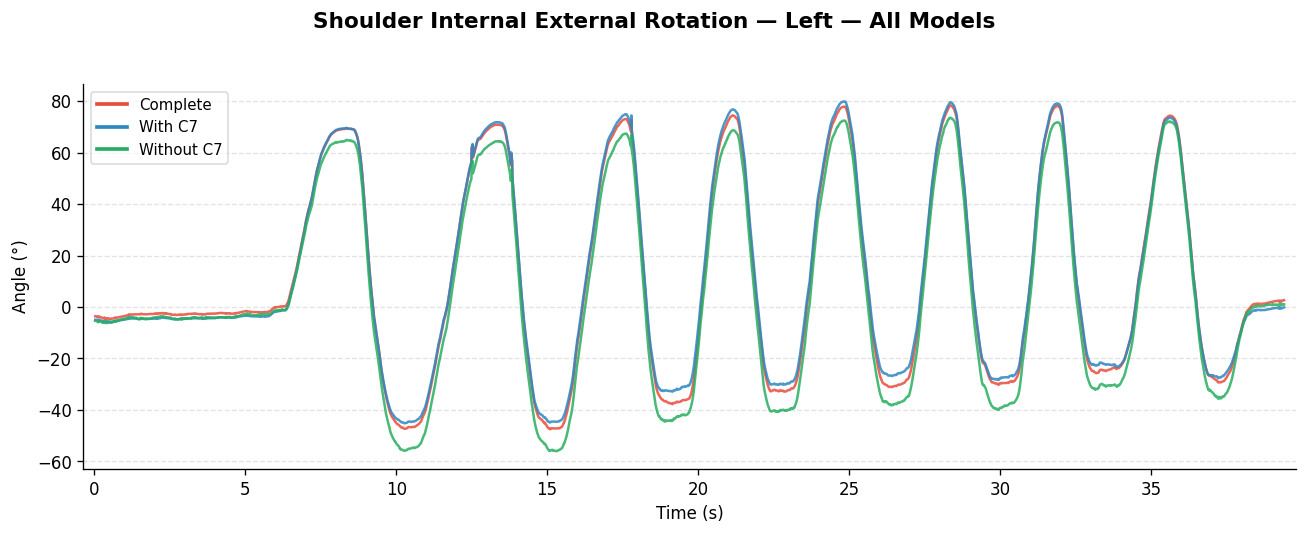

[Right] Reading: Pie_Complete_Shoulder_Rotac_Int_Ext_Right_Cont01.c3d
[Right] Reading: Pie_C7_Shoulder_Rotac_Int_Ext_Right_Cont01.c3d
[Right] Reading: Pie_NOT_C7_Shoulder_Rotac_Int_Ext_Right_Cont01.c3d


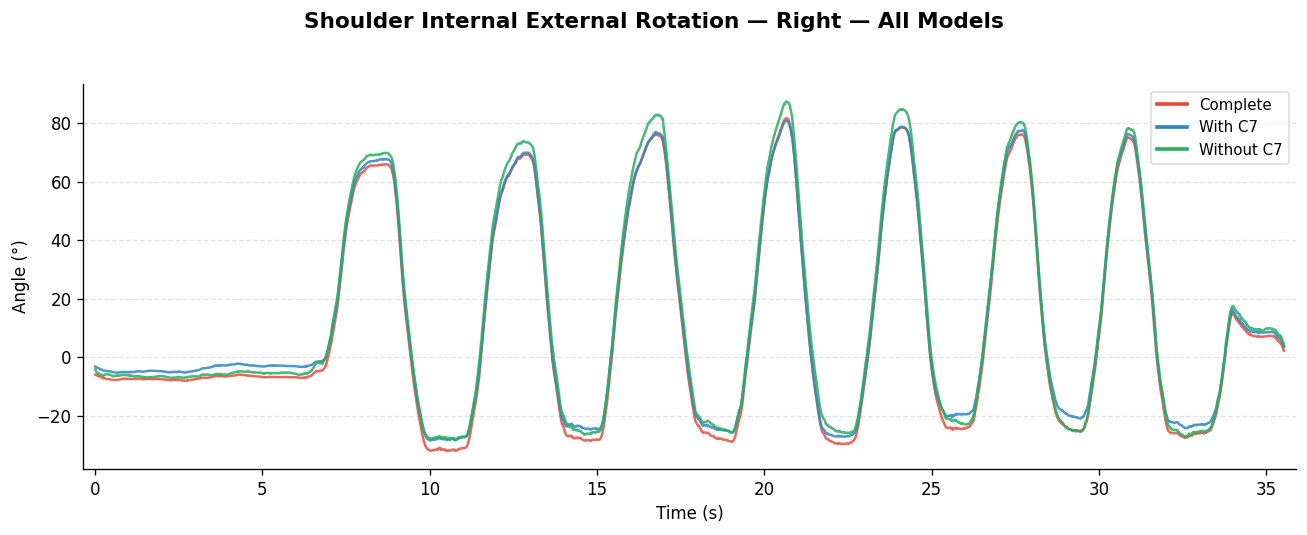

In [6]:
# ── Generate the angle vs. time plot ─────────────────────────────────────────

for SIDE, C3D_RECORDINGS in SIDES_RECORDINGS.items():
    fig, ax = plt.subplots(figsize=(11, 4.5))
    fig.subplots_adjust(top=0.88)
    fig.suptitle(f"{MOVEMENT_NAME} — {SIDE} — All Models", fontsize=13, fontweight="bold")

    legend_handles = []

    for i, rec in enumerate(C3D_RECORDINGS):
        color = COLORS[i % len(COLORS)]
        print(f"[{SIDE}] Reading: {os.path.basename(rec['path'])}")
        angle, fr = extract_angle(rec["path"], VARIABLE_NAME, COMPONENT_INDEX, SIDE)

        if SHOW_MEAN_BAND:
            t, mean, std, n_reps = mean_band(angle, PROMINENCE, MIN_DISTANCE, HALFCYCLE_DIRECTION)
            ax.plot(t, mean, color=color, linewidth=LINE_WIDTH + 0.3, alpha=ALPHA_RAW)
            ax.fill_between(t, mean - std, mean + std, color=color, alpha=ALPHA_BAND)
            lbl = f"{rec['label']}  (n={n_reps} reps)"
        else:
            t = np.arange(len(angle)) / fr
            if NORMALIZE_TIME:
                t = t / t[-1] * 100.0
            ax.plot(t, angle, color=color, linewidth=LINE_WIDTH, alpha=ALPHA_RAW)
            lbl = rec["label"]

        legend_handles.append(mlines.Line2D([], [], color=color, linewidth=2.2, label=lbl))

    if SHOW_MEAN_BAND:
        ax.set_xlabel("Normalized Cycle (%)", fontsize=10)
    elif NORMALIZE_TIME:
        ax.set_xlabel("Normalized Time (%)", fontsize=10)
    else:
        ax.set_xlabel("Time (s)", fontsize=10)

    ax.set_ylabel(Y_LABEL, fontsize=10)
    ax.legend(handles=legend_handles, fontsize=9, framealpha=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35, zorder=0)
    ax.margins(x=0.01)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if OUTPUT_PATH:
        out = OUTPUT_PATH.replace(".", f"_{SIDE}.")
        fig.savefig(out, dpi=DPI, bbox_inches="tight")
        print(f"Saved to: {out}")

    plt.show()

In [7]:
# ── Compute differences for all 3 model pairs ────────────────────────────────

data_by_side = {}

for SIDE, C3D_RECORDINGS in SIDES_RECORDINGS.items():
    raw_signals = {}
    frame_rates = {}
    for rec in C3D_RECORDINGS:
        angle, fr = extract_angle(rec["path"], VARIABLE_NAME, COMPONENT_INDEX, SIDE)
        raw_signals[rec["label"]] = angle
        frame_rates[rec["label"]] = fr

    min_frames = min(len(v) for v in raw_signals.values())
    signals    = {k: v[:min_frames] for k, v in raw_signals.items()}

    fr_ref        = frame_rates["Complete"]
    t_s           = np.arange(min_frames) / fr_ref
    diff_c7       = signals["With C7"]    - signals["Complete"]
    diff_no_c7    = signals["Without C7"] - signals["Complete"]
    diff_c7_no_c7 = signals["With C7"]    - signals["Without C7"]

    data_by_side[SIDE] = {
        "signals":        signals,
        "t_s":            t_s,
        "diff_c7":        diff_c7,
        "diff_no_c7":     diff_no_c7,
        "diff_c7_no_c7":  diff_c7_no_c7,
        "min_frames":     min_frames,
        "fr_ref":         fr_ref,
    }

    print(f"[{SIDE}] Frames used: {min_frames}  ({min_frames / fr_ref:.2f} s)")

[Left] Frames used: 3942  (39.42 s)
[Right] Frames used: 3555  (35.55 s)


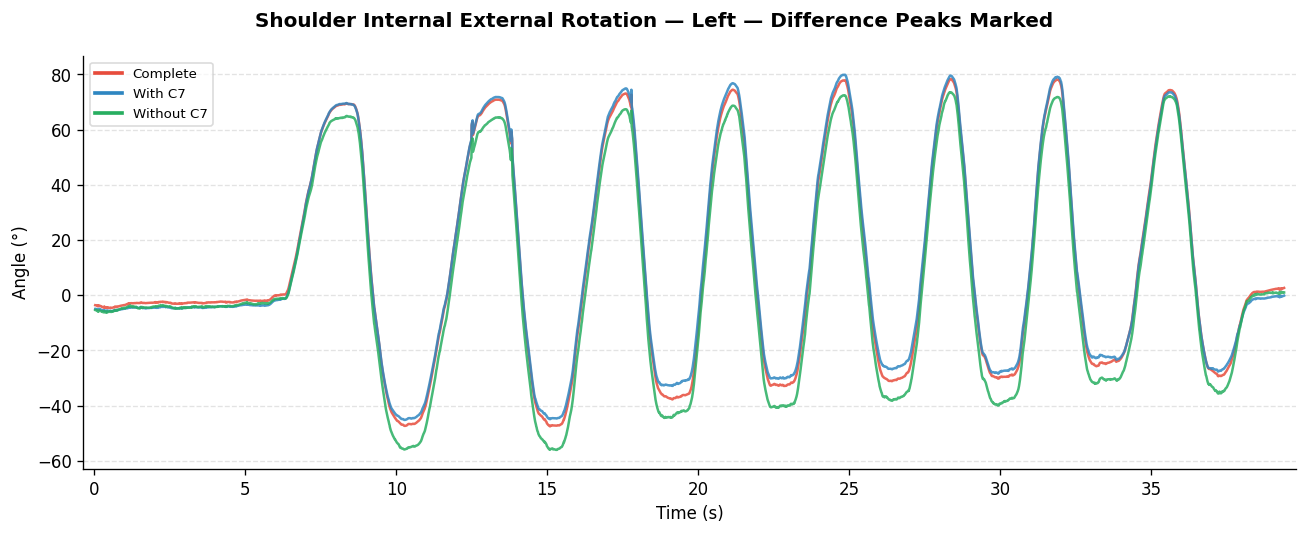


[Left] Threshold: MAD + 2.0σ

Complete − With C7  (threshold = nan°):
  No prominent peaks

Complete − Without C7  (threshold = nan°):
  No prominent peaks

With C7 − Without C7  (threshold = nan°):
  No prominent peaks


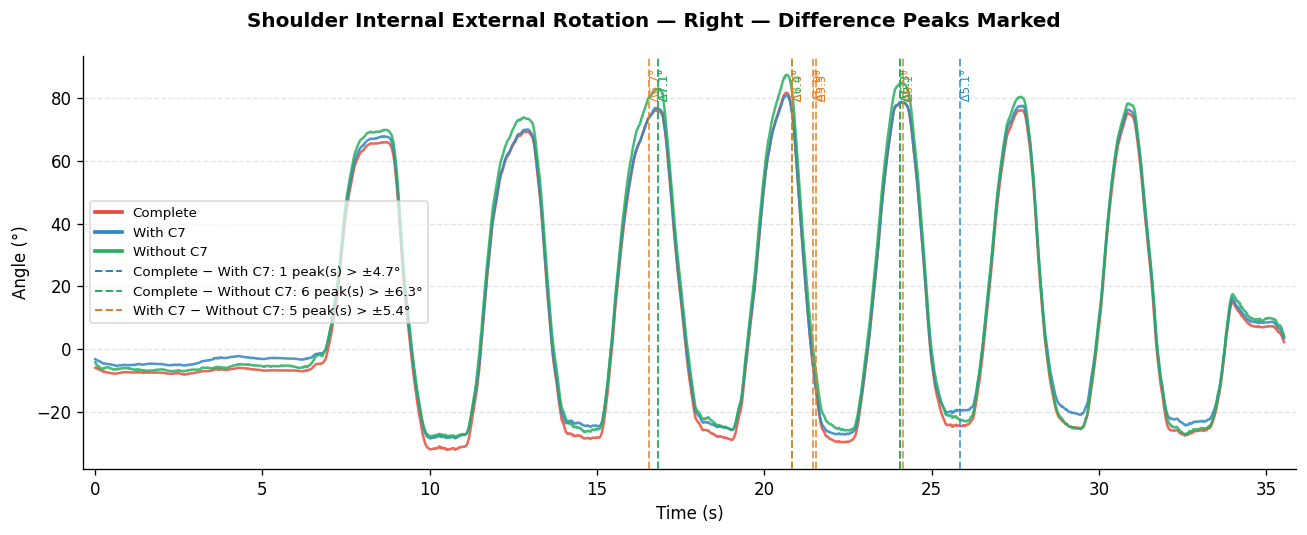


[Right] Threshold: MAD + 2.0σ

Complete − With C7  (threshold = 4.69°):
  t = 25.85 s  →  Δ = 5.07°

Complete − Without C7  (threshold = 6.30°):
  t = 16.81 s  →  Δ = 7.14°
  t = 16.81 s  →  Δ = 7.14°
  t = 20.82 s  →  Δ = 6.39°
  t = 24.07 s  →  Δ = 6.32°
  t = 24.07 s  →  Δ = 6.32°
  t = 24.07 s  →  Δ = 6.32°

With C7 − Without C7  (threshold = 5.43°):
  t = 16.56 s  →  Δ = 6.67°
  t = 20.82 s  →  Δ = 7.03°
  t = 21.45 s  →  Δ = 5.93°
  t = 21.56 s  →  Δ = 5.53°
  t = 24.15 s  →  Δ = 6.09°


In [8]:
# ── Locate prominent difference spikes — all 3 model pairs ───────────────────
# A spike is considered prominent if it exceeds SPIKE_THRESHOLD standard
# deviations above the mean absolute deviation (MAD).
# ─────────────────────────────────────────────────────────────────────────────

SPIKE_THRESHOLD = 2.0   # ← adjust: how many σ above MAD to mark a spike

def _find_spike_times(diff, t, threshold_sd):
    """Returns times (s) where |diff| exceeds mean(|diff|) + threshold_sd * std(|diff|)."""
    abs_diff = np.abs(diff)
    cutoff   = abs_diff.mean() + threshold_sd * abs_diff.std()
    above    = abs_diff > cutoff
    starts   = np.where(np.diff(above.astype(int)) == 1)[0]
    peaks    = [s + np.argmax(abs_diff[s: s + 50]) for s in starts]
    return t[peaks], abs_diff[peaks], cutoff

PAIR_INFO = [
    ("Complete − With C7",    "#2E86C1"),
    ("Complete − Without C7", "#27AE60"),
    ("With C7 − Without C7",  "#E67E22"),
]

for SIDE, d in data_by_side.items():
    signals        = d["signals"]
    t_s            = d["t_s"]
    min_frames     = d["min_frames"]
    C3D_RECORDINGS = SIDES_RECORDINGS[SIDE]

    diff_keys  = ["diff_c7", "diff_no_c7", "diff_c7_no_c7"]
    spike_info = [
        (label, color, _find_spike_times(d[key], t_s, SPIKE_THRESHOLD))
        for (label, color), key in zip(PAIR_INFO, diff_keys)
    ]

    fig, ax = plt.subplots(figsize=(11, 4.5))
    fig.suptitle(f"{MOVEMENT_NAME} — {SIDE} — Difference Peaks Marked",
                 fontsize=12, fontweight="bold")

    legend_handles = []
    for i, rec in enumerate(C3D_RECORDINGS):
        color = COLORS[i % len(COLORS)]
        angle = signals[rec["label"]]
        ax.plot(t_s, angle[:min_frames], color=color, linewidth=LINE_WIDTH, alpha=ALPHA_RAW)
        legend_handles.append(mlines.Line2D([], [], color=color, linewidth=2.2, label=rec["label"]))

    for label, color, (times, magnitudes, cutoff) in spike_info:
        for tk, mag in zip(times, magnitudes):
            ax.axvline(tk, color=color, linewidth=1.2, linestyle="--", alpha=0.75, zorder=4)
            ylim = ax.get_ylim()
            ax.text(tk, ylim[0] + (ylim[1] - ylim[0]) * 0.97,
                    f" Δ{mag:.1f}°", color=color, fontsize=7,
                    va="top", rotation=90, zorder=5)
        if len(times):
            legend_handles.append(
                mlines.Line2D([], [], color=color, linewidth=1.2, linestyle="--",
                              label=f"{label}: {len(times)} peak(s) > ±{cutoff:.1f}°")
            )

    ax.set_xlabel("Time (s)", fontsize=10)
    ax.set_ylabel(Y_LABEL, fontsize=10)
    ax.legend(handles=legend_handles, fontsize=8, framealpha=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35, zorder=0)
    ax.locator_params(axis="y", nbins=12)
    ax.margins(x=0.01)
    plt.tight_layout()
    plt.show()

    print(f"\n[{SIDE}] Threshold: MAD + {SPIKE_THRESHOLD}σ")
    for label, _, (times, magnitudes, cutoff) in spike_info:
        print(f"\n{label}  (threshold = {cutoff:.2f}°):")
        if len(times) == 0:
            print("  No prominent peaks")
        for tk, mag in zip(times, magnitudes):
            print(f"  t = {tk:.2f} s  →  Δ = {mag:.2f}°")


[Left]
                                  Complete − With C7         Complete − Without C7          With C7 − Without C7
RMSD (°)                                       1.988                         5.619                         7.150
MAD (°)                                        1.695                         5.099                         6.144
max_diff (°)                                   5.335                         9.871                        11.977
mean_bias (°)                                  0.871                        -5.099                         5.971
Pearson r                                      0.999                         0.998                         0.995
ICC(3,1) [95% CI]               0.999 [0.999, 0.999]          0.998 [0.998, 0.998]          0.995 [0.994, 0.995]
                                  99.9% valid frames            99.9% valid frames            99.9% valid frames


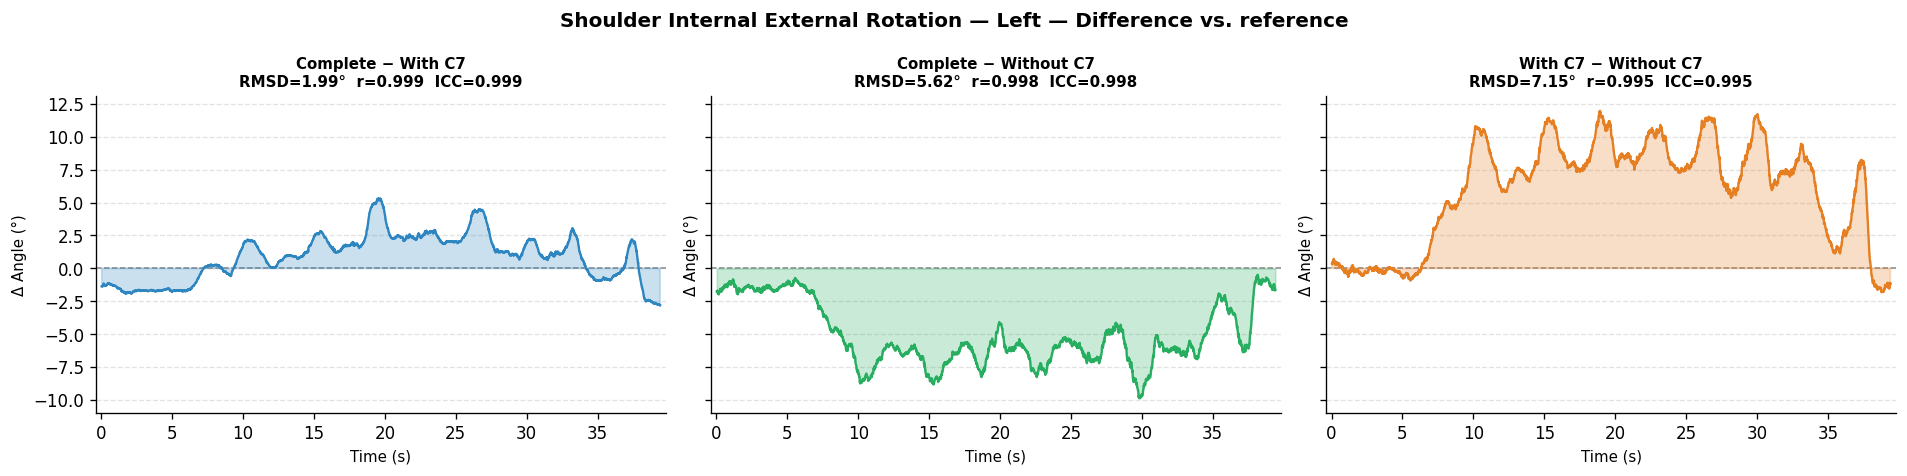


[Right]
                                  Complete − With C7         Complete − Without C7          With C7 − Without C7
RMSD (°)                                       2.570                         3.459                         2.803
MAD (°)                                        2.267                         3.055                         2.340
max_diff (°)                                   5.066                         7.141                         7.034
mean_bias (°)                                  2.237                         3.050                        -0.813
Pearson r                                      1.000                         0.999                         0.999
ICC(3,1) [95% CI]               0.999 [0.999, 0.999]          0.999 [0.999, 0.999]          0.997 [0.997, 0.997]
                                 100.0% valid frames           100.0% valid frames           100.0% valid frames


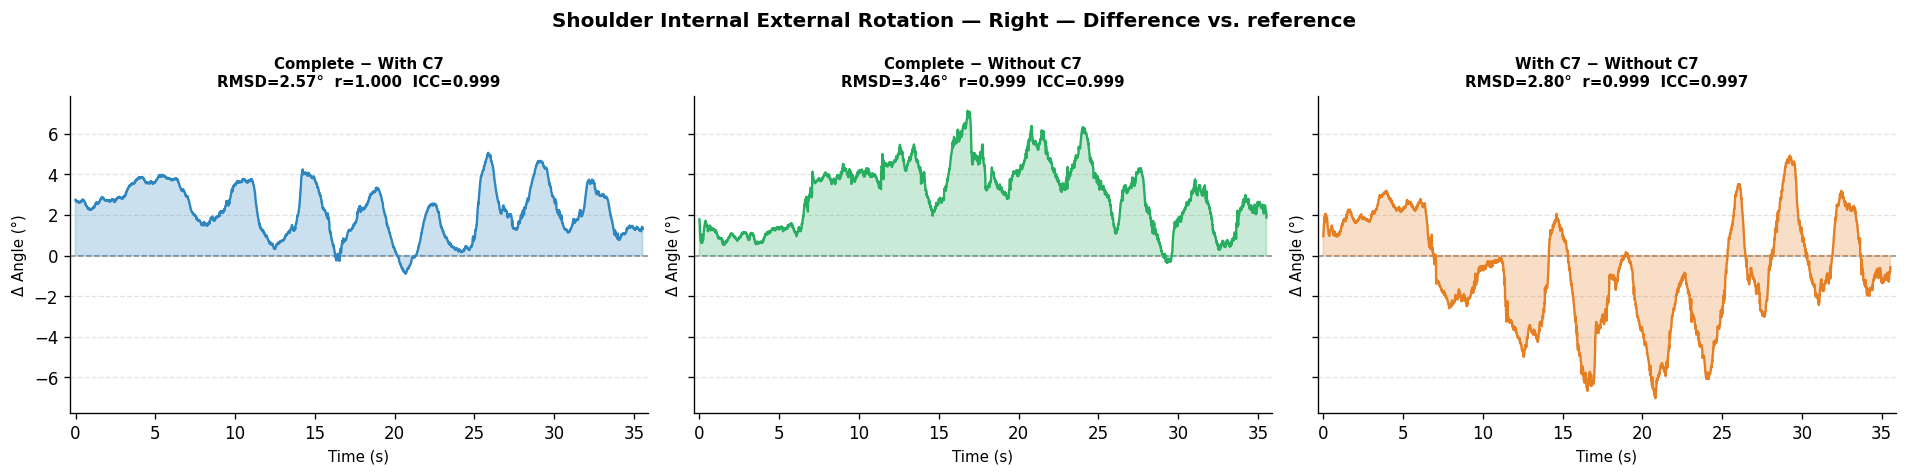

In [9]:
# ── Angular difference plots + metrics for all 3 model pairs ─────────────────
from scipy.stats import pearsonr, f as f_dist

def _icc3(a, b):
    """ICC(3,1) two-way fixed, single measures, consistency. Returns (icc, ci_lo, ci_hi)."""
    n, k   = len(a), 2
    data   = np.column_stack([a, b])
    grand  = data.mean()
    r_mean = data.mean(axis=1)
    c_mean = data.mean(axis=0)
    ss_row = k * np.sum((r_mean - grand)**2)
    ss_col = n * np.sum((c_mean - grand)**2)
    ss_err = np.sum((data - grand)**2) - ss_row - ss_col
    ms_row = ss_row / (n - 1)
    ms_err = ss_err / ((n - 1) * (k - 1))
    icc    = (ms_row - ms_err) / (ms_row + (k - 1) * ms_err)
    F      = ms_row / ms_err
    Fc_hi  = f_dist.ppf(0.975, n - 1, (n - 1) * (k - 1))
    Fc_lo  = f_dist.ppf(0.975, (n - 1) * (k - 1), n - 1)
    ci_lo  = np.clip((F / Fc_hi - 1) / (F / Fc_hi + k - 1), -1, 1)
    ci_hi  = np.clip((F * Fc_lo - 1) / (F * Fc_lo + k - 1), -1, 1)
    return float(icc), float(ci_lo), float(ci_hi)


def _stats(diff, sig_a, sig_b):
    # Drop frames where any signal has NaN (marker gaps)
    valid  = ~(np.isnan(diff) | np.isnan(sig_a) | np.isnan(sig_b))
    dv, av, bv = diff[valid], sig_a[valid], sig_b[valid]
    pct = 100 * valid.mean()
    r, _        = pearsonr(av, bv)
    icc, lo, hi = _icc3(av, bv)
    return {
        "RMSD":      np.sqrt(np.mean(dv**2)),
        "MAD":       np.mean(np.abs(dv)),
        "max_diff":  np.max(np.abs(dv)),
        "mean_bias": np.mean(dv),
        "pearson_r": r,
        "icc":       icc,
        "icc_lo":    lo,
        "icc_hi":    hi,
        "pct_valid": pct,
    }


PAIR_INFO = [
    ("Complete − With C7",    "#2E86C1"),
    ("Complete − Without C7", "#27AE60"),
    ("With C7 − Without C7",  "#E67E22"),
]

for SIDE, d in data_by_side.items():
    t_s       = d["t_s"]
    sigs      = d["signals"]
    diff_list = [d["diff_c7"], d["diff_no_c7"], d["diff_c7_no_c7"]]
    sig_pairs = [
        (sigs["Complete"], sigs["With C7"]),
        (sigs["Complete"], sigs["Without C7"]),
        (sigs["With C7"],  sigs["Without C7"]),
    ]

    stats_all = [_stats(diff, a, b) for diff, (a, b) in zip(diff_list, sig_pairs)]

    # --- Stats table ---------------------------------------------------------
    print(f"\n[{SIDE}]")
    w = 28
    print(f"{'':22s}" + "".join(f"  {lbl:>{w}}" for lbl, _ in PAIR_INFO))
    for key, name in [
        ("RMSD",      "RMSD (°)"),
        ("MAD",       "MAD (°)"),
        ("max_diff",  "max_diff (°)"),
        ("mean_bias", "mean_bias (°)"),
        ("pearson_r", "Pearson r"),
    ]:
        print(f"{name:22s}" + "".join(f"  {s[key]:>{w}.3f}" for s in stats_all))
    icc_strs = [f"{s['icc']:.3f} [{s['icc_lo']:.3f}, {s['icc_hi']:.3f}]" for s in stats_all]
    print(f"{'ICC(3,1) [95% CI]':22s}" + "".join(f"  {v:>{w}}" for v in icc_strs))
    pct_strs = [f"{s['pct_valid']:.1f}% valid frames" for s in stats_all]
    print(f"{'':22s}" + "".join(f"  {v:>{w}}" for v in pct_strs))

    # --- Difference waveform plots -------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
    fig.suptitle(f"{MOVEMENT_NAME} — {SIDE} — Difference vs. reference",
                 fontsize=12, fontweight="bold")

    for ax, diff, (label, color), s in zip(axes, diff_list, PAIR_INFO, stats_all):
        ax.axhline(0, color="gray", linewidth=0.9, linestyle="--", zorder=1)
        ax.fill_between(t_s, diff, 0, where=(diff >= 0), color=color, alpha=0.25, zorder=2)
        ax.fill_between(t_s, diff, 0, where=(diff <  0), color=color, alpha=0.25, zorder=2)
        ax.plot(t_s, diff, color=color, linewidth=1.4, zorder=3)
        ax.set_title(f"{label}\nRMSD={s['RMSD']:.2f}°  r={s['pearson_r']:.3f}  ICC={s['icc']:.3f}",
                     fontsize=9, fontweight="bold")
        ax.set_xlabel("Time (s)", fontsize=9)
        ax.set_ylabel("Δ Angle (°)", fontsize=9)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.yaxis.grid(True, linestyle="--", alpha=0.35, zorder=0)
        ax.locator_params(axis="y", nbins=10)
        ax.margins(x=0.01)

    plt.tight_layout()
    plt.show()

---
## Physical vs Virtual Marker Distances

3D Euclidean distance (mm) between physical markers in the **Complete** model and their virtual equivalents in the modified models, frame by frame.

| Comparison | Physical marker | Virtual marker | Models |
|---|---|---|---|
| T8 | `T8_ocst` (Complete) | `T8_V` | Complete vs With C7 · Complete vs Without C7 |
| C7 | `C7_ocst` (Complete) | `C7_V` | Complete vs Without C7 only (With C7 has the physical C7) |


── Left ──
  T8_ocst (Complete)        → found: 'T8_ocst'
  T8_V   (With C7)          → found: 'T8_V'
  T8_V   (Without C7)       → found: 'T8_V'
  C7_ocst (Complete)        → found: 'C7_ocst'
  C7_V   (Without C7)       → found: 'C7_Virtual'


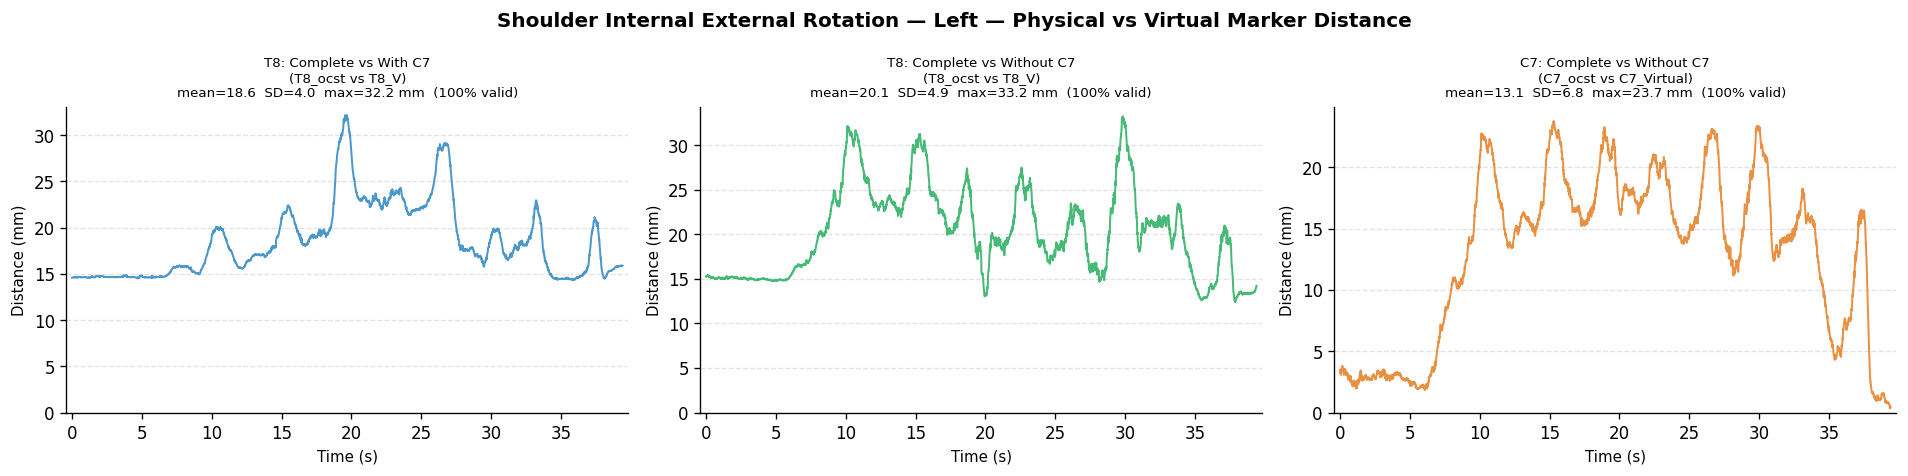

  T8: Complete vs With C7     mean=  18.6 mm  SD=  4.0 mm  max=  32.2 mm  valid=100.0%
  T8: Complete vs Without C7  mean=  20.1 mm  SD=  4.9 mm  max=  33.2 mm  valid=100.0%
  C7: Complete vs Without C7  mean=  13.1 mm  SD=  6.8 mm  max=  23.7 mm  valid=100.0%

── Right ──
  T8_ocst (Complete)        → found: 'T8_ocst'
  T8_V   (With C7)          → found: 'T8_V'
  T8_V   (Without C7)       → found: 'T8_V'
  C7_ocst (Complete)        → found: 'C7_ocst'
  C7_V   (Without C7)       → found: 'C7_Virtual'


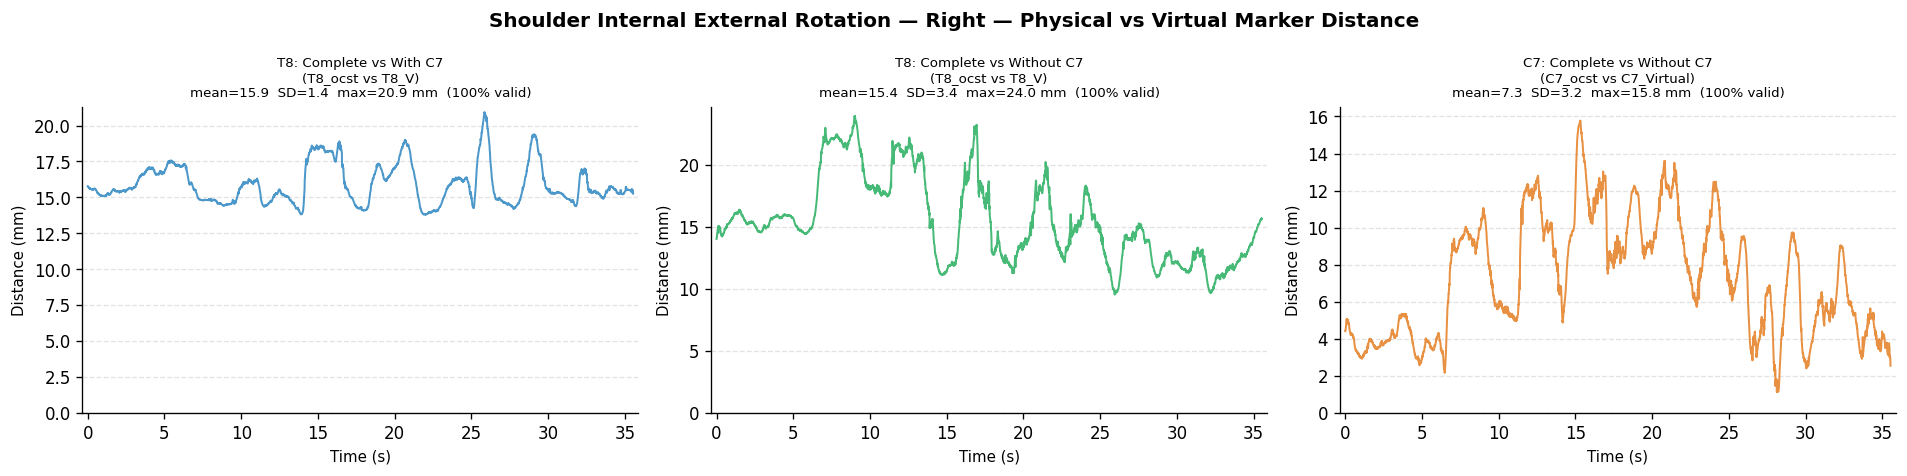

  T8: Complete vs With C7     mean=  15.9 mm  SD=  1.4 mm  max=  20.9 mm  valid=100.0%
  T8: Complete vs Without C7  mean=  15.4 mm  SD=  3.4 mm  max=  24.0 mm  valid=100.0%
  C7: Complete vs Without C7  mean=   7.3 mm  SD=  3.2 mm  max=  15.8 mm  valid=100.0%


In [10]:

# ── Physical vs Virtual Marker Distances ──────────────────────────────────────

def _read_positions(filepath):
    """Returns dict: label → (3, n_frames) XYZ position array in mm."""
    filepath = os.path.normpath(os.path.abspath(filepath))
    c = ezc3d.c3d(filepath)
    raw_labels = c["parameters"]["POINT"]["LABELS"]["value"]
    point_data = c["data"]["points"]
    n_labels   = min(len(raw_labels), point_data.shape[1])
    clean      = [lbl.split(":")[-1].strip() for lbl in raw_labels[:n_labels]]
    return {lbl: point_data[:3, i, :].copy() for i, lbl in enumerate(clean)}

def _find_label(mo, substr):
    for k in mo:
        if substr.upper() in k.upper():
            return k
    return None

def _marker_dist(pos_a, pos_b):
    n    = min(pos_a.shape[1], pos_b.shape[1])
    a, b = pos_a[:, :n].astype(float), pos_b[:, :n].astype(float)
    dist = np.sqrt(np.sum((a - b) ** 2, axis=0))
    dist[np.any(np.isnan(a), axis=0) | np.any(np.isnan(b), axis=0)] = np.nan
    return dist

def _dist_stats(dist):
    v = dist[~np.isnan(dist)]
    if len(v) == 0:
        return None
    return {"mean": v.mean(), "std": v.std(), "max": v.max(),
            "pct": 100 * len(v) / len(dist)}

def _plot_dist_ax(ax, t, dist, title, color):
    n = min(len(t), len(dist)) if dist is not None else 0
    if dist is None:
        ax.text(0.5, 0.5, "marker not found", ha="center", va="center",
                fontsize=10, color="gray", transform=ax.transAxes)
        ax.set_title(title, fontsize=8)
    else:
        s = _dist_stats(dist)
        ax.plot(t[:n], dist[:n], color=color, linewidth=1.2, alpha=0.85)
        if s:
            ax.set_title(
                f"{title}\nmean={s['mean']:.1f}  SD={s['std']:.1f}  max={s['max']:.1f} mm  ({s['pct']:.0f}% valid)",
                fontsize=8)
        else:
            ax.set_title(f"{title}\nNo valid frames", fontsize=8)
    ax.set_xlabel("Time (s)", fontsize=9)
    ax.set_ylabel("Distance (mm)", fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35, zorder=0)
    ax.set_ylim(bottom=0)
    ax.margins(x=0.01)


for SIDE, C3D_RECORDINGS in SIDES_RECORDINGS.items():
    print(f"\n── {SIDE} ──")
    recs = {r["label"]: r["path"] for r in C3D_RECORDINGS}

    mo_complete = _read_positions(recs["Complete"])
    mo_c7       = _read_positions(recs["With C7"])
    mo_no_c7    = _read_positions(recs["Without C7"])

    fr_mk = read_c3d(recs["Complete"])["frame_rate"]
    n_mk  = min(next(iter(mo_complete.values())).shape[1],
                next(iter(mo_c7.values())).shape[1],
                next(iter(mo_no_c7.values())).shape[1])
    t_mk  = np.arange(n_mk) / fr_mk

    t8_phys      = _find_label(mo_complete, "T8_ocst")
    t8_virt_c7   = _find_label(mo_c7,    "T8_V") or _find_label(mo_c7,    "T8v")
    t8_virt_noc7 = _find_label(mo_no_c7, "T8_V") or _find_label(mo_no_c7, "T8v")
    c7_phys      = _find_label(mo_complete, "C7_ocst")
    c7_virt_noc7 = _find_label(mo_no_c7, "C7_V") or _find_label(mo_no_c7, "C7v")

    for name, found in [
        ("T8_ocst (Complete)",  t8_phys),
        ("T8_V   (With C7)",    t8_virt_c7),
        ("T8_V   (Without C7)", t8_virt_noc7),
        ("C7_ocst (Complete)",  c7_phys),
        ("C7_V   (Without C7)", c7_virt_noc7),
    ]:
        print(f"  {name:25s} → {'found: ' + repr(found) if found else 'NOT FOUND'}")

    def _safe_dist(mo_a, key_a, mo_b, key_b):
        if key_a is None or key_b is None:
            return None
        return _marker_dist(mo_a[key_a][:, :n_mk], mo_b[key_b][:, :n_mk])

    dist_t8_c7    = _safe_dist(mo_complete, t8_phys, mo_c7,    t8_virt_c7)
    dist_t8_no_c7 = _safe_dist(mo_complete, t8_phys, mo_no_c7, t8_virt_noc7)
    dist_c7_no_c7 = _safe_dist(mo_complete, c7_phys, mo_no_c7, c7_virt_noc7)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f"{MOVEMENT_NAME} — {SIDE} — Physical vs Virtual Marker Distance",
                 fontsize=12, fontweight="bold")
    _plot_dist_ax(axes[0], t_mk, dist_t8_c7,
                  f"T8: Complete vs With C7\n(T8_ocst vs {t8_virt_c7 or 'NOT FOUND'})",     "#2E86C1")
    _plot_dist_ax(axes[1], t_mk, dist_t8_no_c7,
                  f"T8: Complete vs Without C7\n(T8_ocst vs {t8_virt_noc7 or 'NOT FOUND'})", "#27AE60")
    _plot_dist_ax(axes[2], t_mk, dist_c7_no_c7,
                  f"C7: Complete vs Without C7\n(C7_ocst vs {c7_virt_noc7 or 'NOT FOUND'})",  "#E67E22")
    plt.tight_layout()
    plt.show()

    for label, dist in [
        ("T8: Complete vs With C7   ", dist_t8_c7),
        ("T8: Complete vs Without C7", dist_t8_no_c7),
        ("C7: Complete vs Without C7", dist_c7_no_c7),
    ]:
        if dist is None:
            print(f"  {label}  marker not found")
        else:
            s = _dist_stats(dist)
            if s:
                print(f"  {label}  mean={s['mean']:6.1f} mm  SD={s['std']:5.1f} mm  max={s['max']:6.1f} mm  valid={s['pct']:.1f}%")
            else:
                print(f"  {label}  no valid frames")
